# CNN Model For Handwritten Letters

Let's begin by installing and importing the required libraries.




In [ ]:
 #Remove warning messages
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import random

# navigation and read files
import glob
import os

# Read HDF5 binary data format: convenient for large data storage
import h5py

# Read and display images
import matplotlib.pyplot as plt
import imageio
import cv2
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.preprocessing.image import img_to_array
#from tensorflow import keras

# DL dependancies
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout, LeakyReLU,GlobalMaxPooling2D
from tensorflow.keras.metrics import top_k_categorical_accuracy,categorical_accuracy
from tensorflow.keras.callbacks import ModelCheckpoint,ReduceLROnPlateau,EarlyStopping

Now lets download our dataset from kaggle.

In [ ]:
!pip install opendatasets --upgrade --quiet

In [ ]:
import opendatasets as od

In [ ]:
dataset_url = 'https://www.kaggle.com/olgabelitskaya/classification-of-handwritten-letters'
od.download(dataset_url)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: charvyjain
Your Kaggle Key: ··········


  3%|▎         | 10.0M/303M [00:00<00:03, 102MB/s]

100%|██████████| 303M/303M [00:01<00:00, 198MB/s]


Let's save our work to Jovian, before continuing.

In [104]:
project_name='CNN-Model-for-Handwritten-Letters'

In [105]:
import jovian

In [106]:
jovian.commit(project=project_name, environment=None)

[jovian] Detected Colab notebook...
[jovian] Uploading colab notebook to Jovian...
[jovian] Committed successfully! https://jovian.ai/charvyjain3/cnn-model-for-handwritten-letters


'https://jovian.ai/charvyjain3/cnn-model-for-handwritten-letters'

## **About Dataset**  

For the project [this dataset](https://www.kaggle.com/olgabelitskaya/classification-of-handwritten-letters) was used.

The dataset consists of **Russian lowercase handwritten letters**.

* The main dataset `letters.zip` contains 1650 (50x33) color images (32x32x3) with 33 letters and the file with labels is `letters.txt.`  
 * The file **LetterColorImages.h5** consists of preprocessing images of this set.
* The 2nd (additional) dataset `letters2.zip` conatins 5940 (180x33) color images (32x32x3) with 33 letters and the file with labels is `letters2.txt`.
 * The file **LetterColorImages2.h5** consists of preprocessing images of this set.
* The 3rd (additional) dataset `letters3.zip` conatians 6600 (200x33) color images (32x32x3) with 33 letters and the file with labels is `letters2.txt.`
 * The file **LetterColorImages3.h5** consists of preprocessing images of this set.
Image Backgrounds => Background Labels
striped=>0, gridded=>1, no background=>2, graph paper=>3



### Dataset

In [ ]:
PATH_TO_DATA = './classification-of-handwritten-letters/'
CSV_FILES =  ['letters.csv', 'letters2.csv', 'letters3.csv']

### Concatenating the Data


In [ ]:
def import_data(CSV_FILE):
    data = pd.read_csv(PATH_TO_DATA + CSV_FILE)
    # Create path extention for corresponding folders that contains images 
    data['source'] = CSV_FILE[:-4]+'/'
    return data

In [ ]:
data1 = import_data(CSV_FILES[0])
data2 = import_data(CSV_FILES[1])
data3 = import_data(CSV_FILES[2])
data = pd.concat([data1, data2, data3], ignore_index=True)

In [ ]:
jovian.commit(project=project_name, environment=None)

[jovian] Detected Colab notebook...
[jovian] Uploading colab notebook to Jovian...
[jovian] Committed successfully! https://jovian.ai/charvyjain3/cnn-model-for-handwritten-letters


'https://jovian.ai/charvyjain3/cnn-model-for-handwritten-letters'

## Exploring the Data


In [ ]:
data.shape

(14190, 5)

In [ ]:
data.head()

,letter,label,file,background,source
0,а,1,01_01.png,0,letters/
1,а,1,01_02.png,0,letters/
2,а,1,01_03.png,0,letters/
3,а,1,01_04.png,0,letters/
4,а,1,01_05.png,0,letters/


In [ ]:
data.letter.unique()

array(['а', 'б', 'в', 'г', 'д', 'е', 'ё', 'ж', 'з', 'и', 'й', 'к', 'л',
       'м', 'н', 'о', 'п', 'р', 'с', 'т', 'у', 'ф', 'х', 'ц', 'ч', 'ш',
       'щ', 'ъ', 'ы', 'ь', 'э', 'ю', 'я'], dtype=object)

 **Letter Symbols => Letter Labels**

> **а => 1, б => 2, в => 3, г => 4, д => 5, е => 6, ё => 7, ж => 8, з => 9, и => 10,
й => 11, к => 12, л => 13, м => 14, н => 15, о => 16, п => 17, р => 18, с => 19, т => 20, у => 21, ф => 22, х => 23, ц => 24, ч => 25, ш => 26, щ => 27, ъ => 28, ы => 29, ь => 30, э => 31, ю => 32, я => 33**

In [ ]:
data = shuffle(data, random_state = 42)

In [ ]:
data.tail()

,letter,label,file,background,source
5191,т,20,20_172.png,2,letters2/
13418,ь,30,30_259.png,3,letters3/
5390,у,21,21_191.png,2,letters2/
860,р,18,18_11.png,0,letters/
7270,ю,32,32_91.png,2,letters2/


**Now, for each row, we get the letter, its index in letters vector, the handwritten letter as .png file, the background of the paper the letter was written and the source. The goal of the preprocessing step is to encode the background and the letter column.**

In [ ]:
jovian.commit(project=project_name, environment=None)

[jovian] Detected Colab notebook...
[jovian] Uploading colab notebook to Jovian...
[jovian] Committed successfully! https://jovian.ai/charvyjain3/cnn-model-for-handwritten-letters


'https://jovian.ai/charvyjain3/cnn-model-for-handwritten-letters'

## Preprocessing

In [ ]:
# Get all labels in one string
letters = '' 
for letter in data.letter.unique():
    letters += letter
    
# Which letter is written on each image
labels = data.label

There are 33 distinct letters and 4 different backgrounds.

**Backrground Labels:**  
0 => striped  
1 => gridded  
2 => no background  
3 => graph paper

### One-hot Encoding

Let's encode the target (letter) using one-hot encoding. This encoding method means that each column will represent one class (letter) and have a value of 0 or 1, depending on the object's belonging to this class.

In [ ]:
# Functions for one-hot encoding of columns containing letter class and paper background class.
def ohe_letters(label):
    '''
    One hot encoding for the target label
    '''
    resu = np.zeros(len(letters))
    index = letters.index(label)
    resu[index] = 1
    return resu

def ohe_backgrounds(label):
    '''
    One hot encoding for background column
    '''
    resu = np.zeros(len(data.background.unique()))
    resu[label] = 1
    return resu


In [ ]:
data['encoded_letter'] = data['letter'].apply(lambda x:ohe_letters(x))
data['encoded_background'] = data['background'].apply(lambda x:ohe_backgrounds(x))

In [ ]:
data.head()

,letter,label,file,background,source,encoded_letter,encoded_background
6491,щ,27,27_212.png,2,letters2/,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 1.0, 0.0]"
2012,в,3,03_53.png,2,letters2/,"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 1.0, 0.0]"
13295,ы,29,29_336.png,3,letters3/,"[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 1.0]"
11270,с,19,19_311.png,3,letters3/,"[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 1.0]"
12837,щ,27,27_278.png,3,letters3/,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 1.0]"


The data has the correct format, we can now extract the information we need to train a model.

### Reshape, Filter and Normalize

In [ ]:
# Store all png images into one numpy array
images = []
# Will be the target
encoded_labels = []

backgrounds = []
encoded_backgrounds = []

# I want to be sure that every image is consitent
for i, row in data.iterrows():
    img_name = row['file']
    numpy_image = cv2.imread(os.path.join(PATH_TO_DATA + row['source'], img_name))
    if numpy_image.shape == (32, 32, 3):
        images.append(numpy_image)
        encoded_labels.append(row['encoded_letter'])
        backgrounds.append(row['background'])
        encoded_backgrounds.append(row['encoded_background'])
        
# Normalize array of images
images = np.array(images)/255

In [ ]:
len(images), len(encoded_labels)

(14178, 14178)

In [ ]:
def display_image(images_list, list_of_labels = np.arange(9)):
    
    # plot first few images
    plt.figure(figsize=(12,12))
    for index in list_of_labels:
        
        # Get corresponding label
        ohe_label = encoded_labels[index]
        index_letter = list(ohe_label).index(1)
        associated_letter = letters[index_letter]

        # Get background
        associated_background = backgrounds[index]
        
        
        # define subplot
        plt.subplot(330 + 1 + index)
        plt.title('Label: %s \n'%associated_letter+\
                 'Background: %s\n'%associated_background,
                 fontsize=18)
        # plot raw pixel data
        plt.imshow(images[index])
        
    plt.subplots_adjust(bottom = 0.001)  # the bottom of the subplots of the figure
    plt.subplots_adjust(top = 0.99)
    # show the figure
    plt.show()


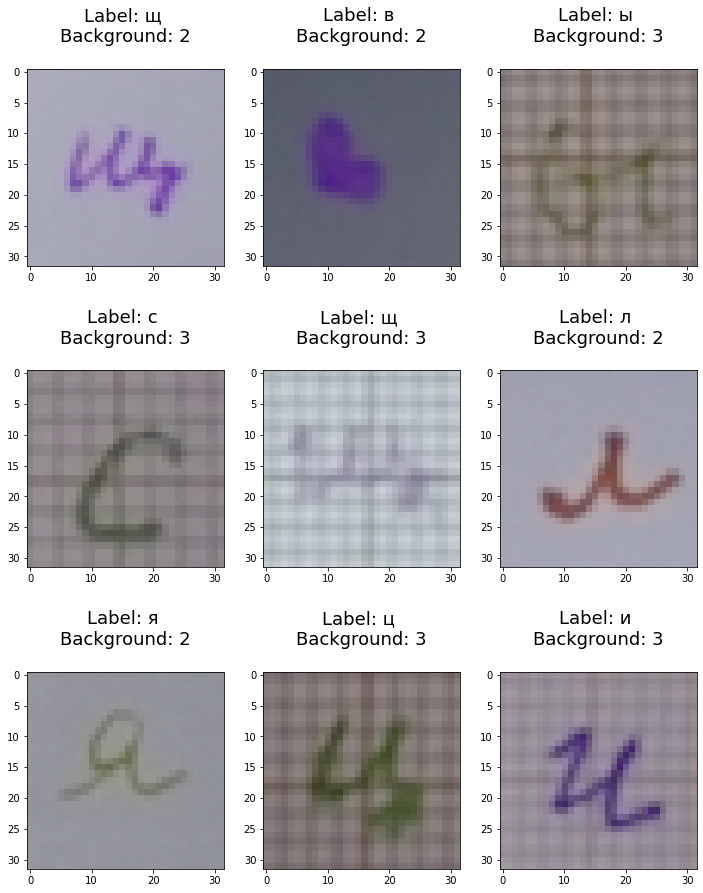

In [ ]:
display_image(images)

In [ ]:
jovian.commit(project=project_name, environment=None)

[jovian] Detected Colab notebook...
[jovian] Uploading colab notebook to Jovian...
[jovian] Committed successfully! https://jovian.ai/charvyjain3/cnn-model-for-handwritten-letters


'https://jovian.ai/charvyjain3/cnn-model-for-handwritten-letters'

## Preparing of Training and Validation set

In [ ]:
# Define X_data and target
X = np.array(images.copy())
y = np.array(encoded_labels.copy())

# Stratified train_test split on labels
X_train, X_val, y_train, y_val = train_test_split(X, y, 
                                                  test_size=.2, 
                                                  stratify = y, 
                                                  random_state=42)
X_train.shape, X_val.shape, y_train.shape, y_val.shape

((11342, 32, 32, 3), (2836, 32, 32, 3), (11342, 33), (2836, 33))

We're all set and the data are ready to feed the model. Let's create the model now.

## CNN MODEL

* A CNN is quite similar to Classic Neural Networks (RegularNets) where there are neurons with weights and biases. Just like in RegularNets, we use a loss function and an optimizer in CNNs.  
* Additionally in CNNs, there are Convolutional Layers, Pooling Layers, and Flatten Layers.  
* CNNs are mainly used for image classification.


#### CNN layers  
**Convolutional layer :**
The very first layer where we extract features from the images in our datasets. Convolution is basically filtering the image with a smaller pixel filter to decrease the size of the image without loosing the relationship between pixels. When we apply convolution to 5x5 image by using a 3x3 filter with 1x1 stride (1 pixel shift at each step). We will end up having a 3x3 output (64% decrease in complexity).  

**Pooling layer :**
When constructing CNNs, it is common to insert pooling layers after each convolution layer to reduce the spatial size of the representation to reduce the parameter counts which reduces the computational complexity. In addition, pooling layers also helps with the overfitting problem. Basically we select a pooling size to reduce the amount of the parameters by selecting the maximum, average, or sum values inside these pixels.  

**Flatten layer :**
Flattens the input. Does not affect the batch size.

In [ ]:
jovian.commit(project=project_name, environment=None)

[jovian] Detected Colab notebook...
[jovian] Uploading colab notebook to Jovian...
[jovian] Committed successfully! https://jovian.ai/charvyjain3/cnn-model-for-handwritten-letters


'https://jovian.ai/charvyjain3/cnn-model-for-handwritten-letters'

### Defining Parameters


In [ ]:
 # Define image dimensions
IMG_ROWS = 32
IMG_COLS = 32
# 3 stands for RGB images, 1 if greyscaled images
INPUT_SHAPE = (IMG_ROWS, IMG_COLS, 3)

# Number of classes to consider
NUM_CLASSES = len(letters)
# Group of training samples
BATCH_SIZE = 64
# Number of complete presentations of the dataset to be learned
EPOCHS = 100

### Defining a custom metric

In [ ]:
def top_3_categorical_accuracy(y_true, y_pred):
    return top_k_categorical_accuracy(y_true, y_pred, k=3)

## Creating model

In [ ]:
def CNN_model(activation = 'softmax', 
              loss = 'categorical_crossentropy', 
              optimizer = 'adam', 
              metrics = ['accuracy', top_3_categorical_accuracy]):
    
    model = Sequential()
    model.add(Conv2D(32, kernel_size = (3, 3),
                     activation = 'relu',
                     input_shape = INPUT_SHAPE))
    model.add(Conv2D(64, (3, 3), activation = 'relu'))
    model.add(Conv2D(128, (4, 4), activation = 'relu'))
    model.add(MaxPooling2D(pool_size = (2, 2)))
    model.add(Dropout(0.25))
    model.add(Flatten())
    model.add(Dense(128, activation = 'relu'))
    model.add(Dropout(0.25))
    model.add(Dense(NUM_CLASSES, activation = activation))
    
    # Compile the model
    model.compile(loss = loss,
                  optimizer = optimizer, 
                  metrics = metrics)
    
    return model


In [ ]:
# Init CNN model
cnn_model = CNN_model()

# Save weights only for best model
checkpointer = ModelCheckpoint(filepath = 'weights.best.letters.hdf5', 
                               verbose = 2, 
                               save_best_only = True)

# Reduce learning rate when a metric has stopped improving
lr_reduction = ReduceLROnPlateau(monitor='val_loss', 
                                 patience=10, 
                                 verbose=2, 
                                 factor=.75)

# If score doesn't improve during patience=20 epochs, stop learning
estopping = EarlyStopping(monitor='val_loss', 
                          patience=20, 
                          verbose=2)

# Training
history = cnn_model.fit(X_train, y_train,
                        batch_size = BATCH_SIZE,
                        epochs = EPOCHS,
                        verbose = 1,
                        validation_data = (X_val, y_val),
                        callbacks = [checkpointer, lr_reduction, estopping])

Epoch 1/100
178/178 [==============================] - 176s 985ms/step - loss: 3.4988 - accuracy: 0.0320 - top_3_categorical_accuracy: 0.1028 - val_loss: 3.3158 - val_accuracy: 0.0772 - val_top_3_categorical_accuracy: 0.2186

Epoch 00001: val_loss improved from inf to 3.31577, saving model to weights.best.letters.hdf5
Epoch 2/100
178/178 [==============================] - 173s 971ms/step - loss: 3.0257 - accuracy: 0.1521 - top_3_categorical_accuracy: 0.3326 - val_loss: 2.2492 - val_accuracy: 0.3685 - val_top_3_categorical_accuracy: 0.6040

Epoch 00002: val_loss improved from 3.31577 to 2.24923, saving model to weights.best.letters.hdf5
Epoch 3/100
178/178 [==============================] - 172s 964ms/step - loss: 2.3528 - accuracy: 0.3184 - top_3_categorical_accuracy: 0.5670 - val_loss: 1.8727 - val_accuracy: 0.4704 - val_top_3_categorical_accuracy: 0.7045

Epoch 00003: val_loss improved from 2.24923 to 1.87273, saving model to weights.best.letters.hdf5
Epoch 4/100
178/178 [===========

In [ ]:
# list all data in history
print(history.history.keys())


dict_keys(['loss', 'accuracy', 'top_3_categorical_accuracy', 'val_loss', 'val_accuracy', 'val_top_3_categorical_accuracy', 'lr'])


In [ ]:
jovian.commit(project=project_name, environment=None)

[jovian] Detected Colab notebook...
[jovian] Uploading colab notebook to Jovian...
[jovian] Committed successfully! https://jovian.ai/charvyjain3/cnn-model-for-handwritten-letters


'https://jovian.ai/charvyjain3/cnn-model-for-handwritten-letters'

### Plotting Graphs

In [ ]:
def plot_history(model_history):

    plt.figure(figsize = (20,15))
    
    plt.subplot(221)
    # summarize history for accuracy
    plt.plot(model_history.history['top_3_categorical_accuracy'])
    plt.plot(model_history.history['val_top_3_categorical_accuracy'])
    plt.title('top_3_categorical_accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='upper left')
    plt.grid()
    
    plt.subplot(222)
    # summarize history for accuracy
    plt.plot(model_history.history['accuracy'])
    plt.plot(model_history.history['val_accuracy'])
    plt.title('model accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='upper left')
    plt.grid()
    
    plt.subplot(223)
    # summarize history for loss
    plt.plot(model_history.history['loss'])
    plt.plot(model_history.history['val_loss'])
    plt.title('model loss')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'test'], loc='upper left')
    plt.grid()
    
    plt.subplot(224)
    # summarize history for lr
    plt.plot(model_history.history['lr'])
    plt.title('learning rate')
    plt.ylabel('lr')
    plt.xlabel('epoch')
    plt.grid()
    
    plt.show()


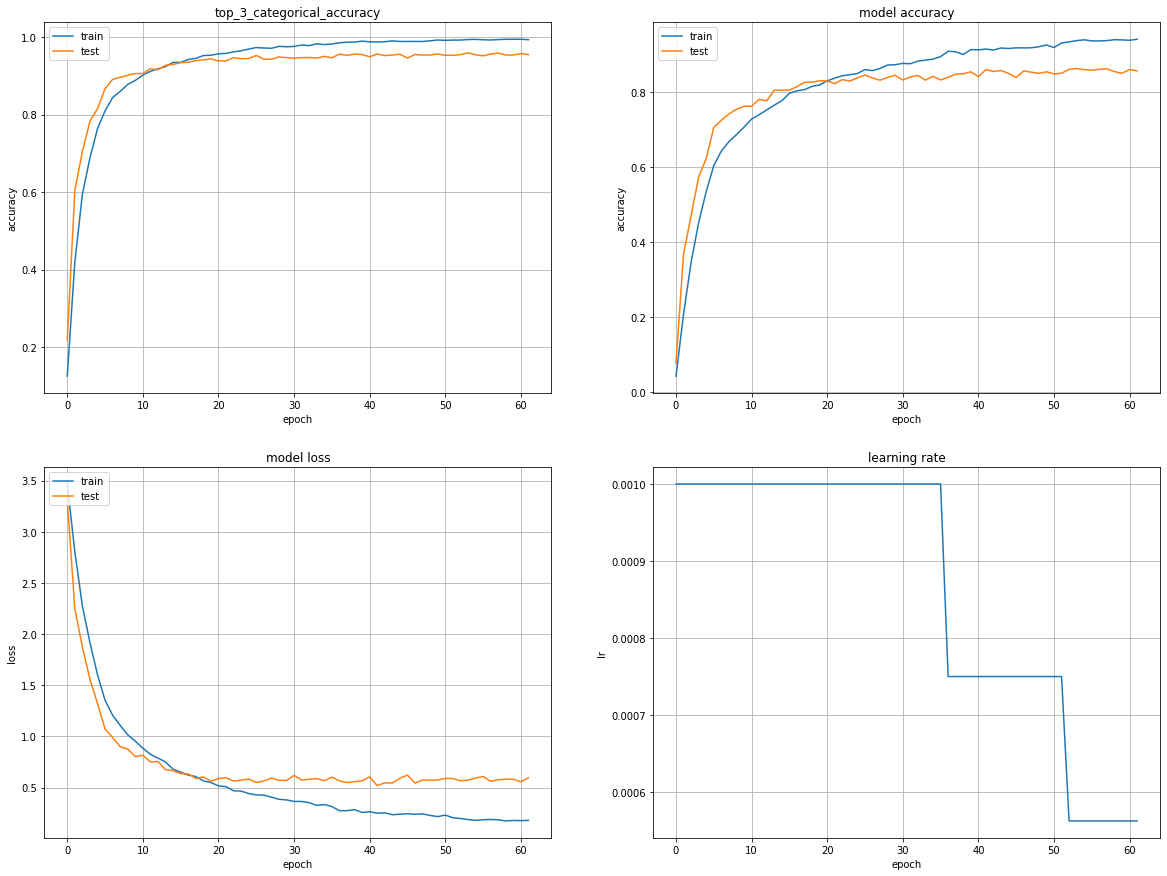

In [ ]:
plot_history(history)

In [ ]:
# loading the model with the best validation accuracy
cnn_model.load_weights('weights.best.letters.hdf5')
cnn_model.evaluate(X_val, y_val)


89/89 [==============================] - 10s 113ms/step - loss: 0.5192 - accuracy: 0.8611 - top_3_categorical_accuracy: 0.9563


[0.5191679000854492, 0.8610719442367554, 0.9562764167785645]

### Loading one prediction

In [ ]:
def load_image(path_filename):
	# load the image
	img = load_img(path_filename, target_size=(32, 32))
	# convert to array
	img = img_to_array(img)
	# reshape into a single sample with 1 channel
	img = img.reshape(1, 32, 32, 3)
	# prepare pixel data
	img = img.astype('float32')
	img = img / 255.0
	return img

In [ ]:
def get_true_label(path_filename, dataframe, column_to_get):
    filename = os.path.basename(os.path.normpath(path_filename))
    index_row = data[data['file']==filename].index[0]
    return data.loc[index_row, column_to_get]


In [ ]:
img = load_image(PATH_TO_DATA+'letters3/01_235.png')


predicted: а
true label: а


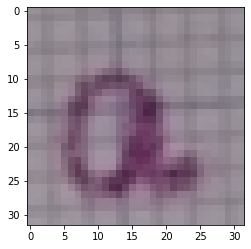

In [ ]:
# predict the class
a_letter = cnn_model.predict_classes(img)

plt.imshow(img[0])
print('predicted:', letters[a_letter[0]])
print('true label:', get_true_label(PATH_TO_DATA+'letters3/01_235.png', data, 'letter'))


### Loading multiple predictions

In [ ]:
def load_random_images(number_of_images_to_load = 9):
    images = []
    true_labels = []
    true_backgrounds = []
    
    which_folder = [random.randint(1,3) for _ in range(number_of_images_to_load)]
    for index_folder in which_folder:
        if index_folder == 1:
            path = PATH_TO_DATA+'letters/'
        else:
            path = PATH_TO_DATA+'letters'+str(index_folder)+'/'
        nb_files = len(os.listdir(path))
        
        index_image = random.randint(0, len(os.listdir(path)))
        
        image = load_image(path + os.listdir(path)[index_image])
        label = get_true_label(path + os.listdir(path)[index_image], data, 'letter')
        background = get_true_label(path + os.listdir(path)[index_image], data, 'background')

        images.append(image)
        true_labels.append(label)
        true_backgrounds.append(background)
        
    return images, true_labels, true_backgrounds


In [ ]:
def classes_predictions(images_list_to_classify, true_labels, model):
    
    # plot first few images
    plt.figure(figsize=(12,12))
    for index, image in enumerate(images_list_to_classify):
        
        a_letter = model.predict_classes(image)
        associated_letter = letters[a_letter[0]]
        
        # define subplot
        plt.subplot(330 + 1 + index)
        plt.title('Predicted Label: %s \n'%associated_letter+\
                  'True Label: %s\n'%true_labels[index],
                 fontsize=18)
        # plot raw pixel data
        plt.imshow(image[0])
        
    plt.subplots_adjust(bottom = 0.001)  # the bottom of the subplots of the figure
    plt.subplots_adjust(top = 0.99)
        
    # show the figure
    plt.show()

In [ ]:
test_images, true_labels, true_backgrounds = load_random_images()

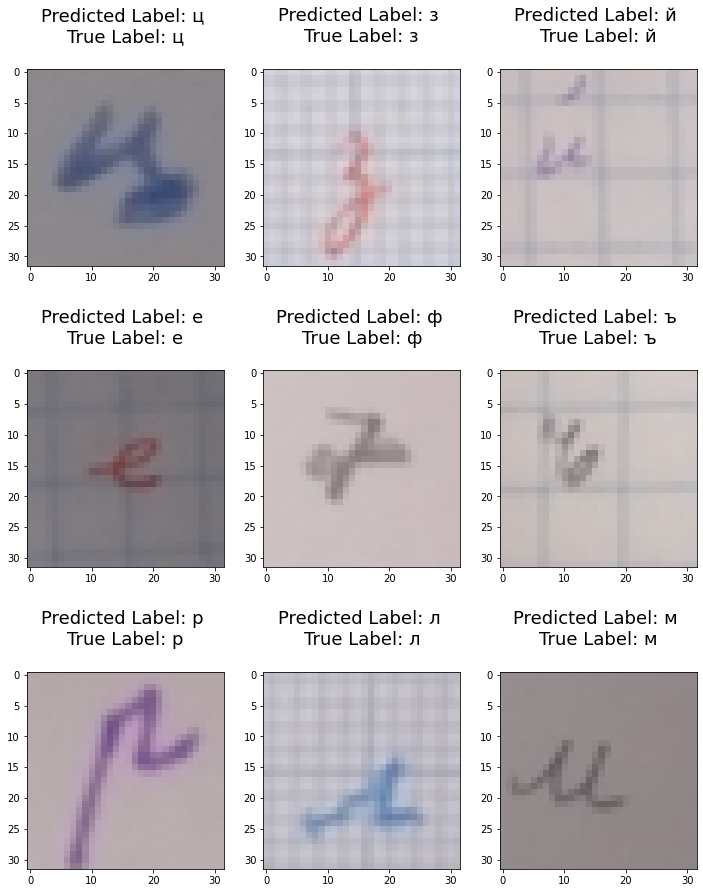

In [ ]:
classes_predictions(test_images, true_labels, cnn_model)

Let's make one final `commit` using jovian.


In [ ]:
jovian.commit(project=project_name)

[jovian] Detected Colab notebook...
[jovian] Uploading colab notebook to Jovian...
